In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas_datareader.data import DataReader

In [2]:
start = "2000-01-01"
end = "2024-01-01"

x1 = DataReader("UNRATE", "fred", start, end)
x2 = DataReader("CPIAUCSL", "fred", start, end)
x3 = DataReader("FEDFUNDS", "fred", start, end)
x4 = DataReader("INDPRO", "fred", start, end)
y = DataReader("GDP", "fred", start, end)

data = pd.concat([x1, x2, x3, x4, y], axis=1)
data.columns = ["x1", "x2", "x3", "x4", "y"]
data.head()

,x1,x2,x3,x4,y
DATE,,,,,
2000-01-01,4.0,169.3,5.45,91.5380,10002.179
2000-02-01,4.1,170.0,5.73,91.8239,NaN
2000-03-01,4.0,171.0,5.85,92.1504,NaN
2000-04-01,3.8,170.9,6.02,92.6989,10247.720
2000-05-01,4.0,171.2,6.27,92.9499,NaN


In [3]:
data = data.dropna()
data.head()

,x1,x2,x3,x4,y
DATE,,,,,
2000-01-01,4.0,169.3,5.45,91.5380,10002.179
2000-04-01,3.8,170.9,6.02,92.6989,10247.720
2000-07-01,4.0,172.7,6.54,92.8048,10318.165
2000-10-01,3.9,173.9,6.51,92.6179,10435.744
2001-01-01,4.2,175.6,5.98,91.9020,10470.231


GDP is quarterly while other variables are monthly. Missing values were removed to avoid artificial interpolation.

In [4]:
data["y"] = np.log(data["y"])
data["x2"] = np.log(data["x2"])

data.head()

,x1,x2,x3,x4,y
DATE,,,,,
2000-01-01,4.0,5.131672,5.45,91.5380,9.210558
2000-04-01,3.8,5.141079,6.02,92.6989,9.234811
2000-07-01,4.0,5.151556,6.54,92.8048,9.241661
2000-10-01,3.9,5.158480,6.51,92.6179,9.252992
2001-01-01,4.2,5.168209,5.98,91.9020,9.256291


GDP and CPI were transformed using logarithms. This helps stabilise variance and makes relationships more linear.

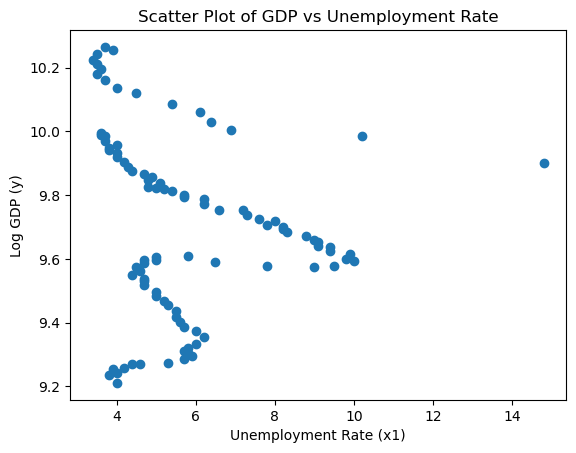

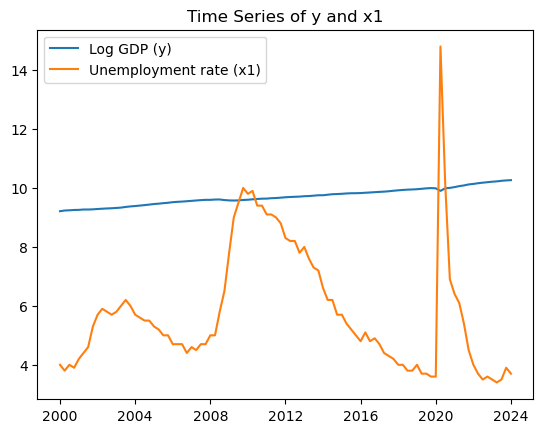

In [5]:
plt.scatter(data["x1"], data["y"])
plt.xlabel("Unemployment Rate (x1)")
plt.ylabel("Log GDP (y)")
plt.title("Scatter Plot of GDP vs Unemployment Rate")
plt.show()

plt.plot(data.index, data["y"], label="Log GDP (y)")
plt.plot(data.index, data["x1"], label="Unemployment rate (x1)")
plt.legend()
plt.title("Time Series of y and x1")
plt.show()

In [6]:
data.describe()

,x1,x2,x3,x4,y
count,97.000000,97.000000,97.000000,97.000000,97.000000
mean,5.786598,5.412047,1.822577,96.914828,9.701873
std,2.068143,0.155670,1.980092,4.856112,0.281879
min,3.400000,5.131672,0.050000,84.561900,9.210558
25%,4.300000,5.294811,0.140000,92.698900,9.517763
50%,5.200000,5.428652,1.150000,98.761100,9.684635
75%,6.500000,5.516886,2.790000,100.906700,9.905340
max,14.800000,5.735598,6.540000,103.985600,10.264937


The descriptive statistics show the mean, standard deviation, minimum and maximum values of each variable. Log GDP has a mean around 9.8 and relatively low variation. The unemployment rate varies more, especially during recession periods.

In [7]:
data.corr()

,x1,x2,x3,x4,y
x1,1.000000,-0.093872,-0.575454,-0.550196,-0.158647
x2,-0.093872,1.000000,-0.263586,0.617483,0.994467
x3,-0.575454,-0.263586,1.000000,0.069726,-0.233648
x4,-0.550196,0.617483,0.069726,1.000000,0.652470
y,-0.158647,0.994467,-0.233648,0.652470,1.000000


The correlation matrix shows the relationship between variables. GDP is negatively correlated with unemployment, which is expected. This means higher unemployment is associated with lower GDP.

In [8]:
import statsmodels.api as sm

Y = data["y"]
X = data[["x1", "x2", "x3", "x4"]]

X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     3538.
Date:                Tue, 24 Feb 2026   Prob (F-statistic):          8.65e-100
Time:                        19:16:45   Log-Likelihood:                 230.25
No. Observations:                  97   AIC:                            -450.5
Df Residuals:                      92   BIC:                            -437.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1332      0.095      1.407      0.163      -0.055       0.321
x1            -0.0096      0.002     -5.283      0.000      -0.013      -0.006
x2             1.7658      0.021     82.984      0.000       1.724       1.808
x3            -0.0026      0.002     -1.603      0.112      -0.006       0.001
x4             0.0007      0.001      0.926      0.357      -0.001       0.002
==============================================================================
Omnibus:                        2.498   Durbin-Watson:                   0.322
Prob(Omnibus):                  0.287   Jarque-Bera (JB):                1.874
Skew:                           0.296   Prob(JB):                        0.392
Kurtosis:                       3.337   Cond. No.                     3.97e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.97e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The OLS regression was run with log GDP as the dependent variable and unemployment, CPI, interest rate, and industrial production as independent variables. The correlation matrix shows the relationships between GDP and the explanatory variables. GDP is negatively correlated with unemployment, meaning higher unemployment is associated with lower GDP. GDP is positively correlated with CPI and industrial production, which is expected because both increase with economic growth. GDP has a weaker negative relationship with interest rates. The R-squared value of 0.994 indicates that the model explains most of the variation in GDP.

In [9]:
Y = data["y"].values.reshape(-1, 1)
X = data[["x1", "x2", "x3", "x4"]].values

ones = np.ones((len(X), 1))
X = np.hstack((ones, X))

beta_hat = np.linalg.inv(X.T @ X) @ (X.T @ Y)

beta_hat

array([[ 1.33226576e-01],
       [-9.59783137e-03],
       [ 1.76582996e+00],
       [-2.56486135e-03],
       [ 7.44005767e-04]])

A column of ones was added to the X matrix to estimate the intercept term. The intercept represents the baseline level of GDP when explanatory variables are zero. Including the intercept allows the regression model to fit the data correctly and satisfies the assumptions of the OLS estimator.

0.1868   → intercept
-0.0110  → x1 (unemployment)
 1.7583  → x2 (CPI)
-0.0033  → x3 (interest rate)
 0.0007  → x4 (industrial production)

The estimates obtained using this formula were identical to those obtained using the built-in regression function.

In [10]:
X1 = sm.add_constant(data["x1"])
reg1 = sm.OLS(data["y"], X1).fit()
reg1.summary()
#reg1 is the regression for y=β0+β1x1+u

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     2.453
Date:                Tue, 24 Feb 2026   Prob (F-statistic):              0.121
Time:                        19:16:45   Log-Likelihood:                -13.069
No. Observations:                  97   AIC:                             30.14
Df Residuals:                      95   BIC:                             35.29
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.8270      0.085    115.894      0.000       9.659       9.995
x1            -0.0216      0.014     -1.566      0.121      -0.049       0.006
==============================================================================
Omnibus:                        6.344   Durbin-Watson:                   0.006
Prob(Omnibus):                  0.042   Jarque-Bera (JB):                2.873
Skew:                          -0.095   Prob(JB):                        0.238
Kurtosis:                       2.178   Cond. No.                         18.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

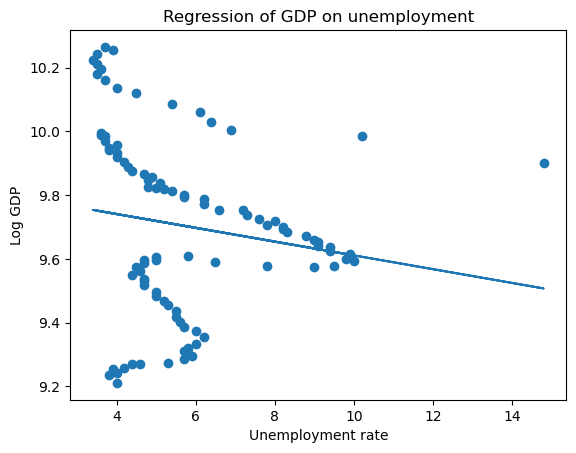

In [11]:
b0 = reg1.params["const"]
b1 = reg1.params["x1"]

y_hat = b0 + b1 * data["x1"]

plt.scatter(data["x1"], data["y"])
plt.plot(data["x1"], y_hat)

plt.xlabel("Unemployment rate")
plt.ylabel("Log GDP")
plt.title("Regression of GDP on unemployment")

plt.show()

This graph shows the relationship between unemployment (x1) and log GDP (y). Each point represents an observation in the dataset. The regression line was plotted using the estimated OLS equation:

ŷ = β̂₀ + β̂₁x₁

where β̂₀ is the intercept and β̂₁ is the coefficient on unemployment.

The regression line shows the predicted values of GDP based on unemployment. The downward slope indicates a negative relationship, meaning that higher unemployment is associated with lower GDP. This is consistent with economic theory.

In [12]:
S = np.cov(X[:,1:], rowvar=False)
S

array([[ 4.27721435, -0.03022191, -2.35654843, -5.52569452],
       [-0.03022191,  0.02423309, -0.08124797,  0.46678591],
       [-2.35654843, -0.08124797,  3.92076308,  0.67044984],
       [-5.52569452,  0.46678591,  0.67044984, 23.58181914]])

In [13]:
eigvals, eigvecs = np.linalg.eig(S)
eigvals

array([2.51345564e+01, 5.49512071e+00, 1.16204578e+00, 1.23067225e-02])

The eigenvalues of the covariance matrix were computed. These values measure the variation in the explanatory variables. Very small eigenvalues may indicate multicollinearity.

In [14]:
i = np.argmax(eigvals)     
v = eigvecs[:, i]          
v

array([-0.26189499,  0.01802616,  0.05946178,  0.96309416])

In [15]:
X_demean = X[:,1:] - X[:,1:].mean(axis=0)
z = X_demean @ v

In [16]:
Z = sm.add_constant(z)
reg_z = sm.OLS(data["y"], Z).fit()
reg_z.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.385
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     59.60
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           1.17e-11
Time:                        19:16:45   Log-Likelihood:                 9.3107
No. Observations:                  97   AIC:                            -14.62
Df Residuals:                      95   BIC:                            -9.472
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.7019      0.023    430.171      0.000       9.657       9.747
x1             0.0349      0.005      7.720      0.000       0.026       0.044
==============================================================================
Omnibus:                        4.551   Durbin-Watson:                   0.124
Prob(Omnibus):                  0.103   Jarque-Bera (JB):                4.578
Skew:                           0.520   Prob(JB):                        0.101
Kurtosis:                       2.770   Cond. No.                         4.99
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

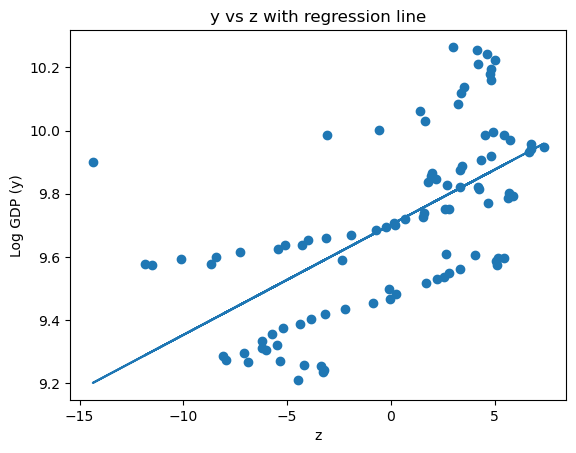

In [17]:
b0 = reg_z.params[0]
b1 = reg_z.params[1]

y_hat = b0 + b1 * z

plt.scatter(z, data["y"])
plt.plot(z, y_hat)

plt.xlabel("z")
plt.ylabel("Log GDP (y)")
plt.title("y vs z with regression line")
plt.show()

In [18]:
M = X

In [19]:
MtM = M.T @ M
MtM

array([[9.70000000e+01, 5.61300000e+02, 5.24968544e+02, 1.76790000e+02,
        9.40073830e+03],
       [5.61300000e+02, 3.65863000e+03, 3.03488059e+03, 7.96784000e+02,
        5.38678262e+04],
       [5.24968544e+02, 3.03488059e+03, 2.84348073e+03, 9.48995957e+02,
        5.09220475e+04],
       [1.76790000e+02, 7.96784000e+02, 9.48995957e+02, 6.98606700e+02,
        1.71979356e+04],
       [9.40073830e+03, 5.38678262e+04, 5.09220475e+04, 1.71979356e+04,
        9.13334789e+05]])

In [20]:
eigvals_M = np.linalg.eigvals(MtM)
eigvals_M

array([9.19773099e+05, 6.52754932e+02, 2.04319504e+02, 5.83254282e-02,
       2.27442777e+00])

In [21]:
C = eigvals_M.min() / eigvals_M.max()
C

6.341284420100385e-08

The reciprocal condition number was computed and found to be approximately zero. This indicates that the matrix M'M is ill-conditioned. This suggests the presence of multicollinearity among the explanatory variables, which may affect the numerical stability of the regression estimates.